In [16]:
### Datos Sintéticos
### Librería SDV
#Fecha: 05 de Junio#
#Autor: Ariana Belinda Pulido Solano#

In [17]:
#Importamos librerías básicas
import pandas as pd
import numpy as np
import random

In [20]:
pip install sdv sdmetrics

  Using cached sdv-1.37.0-py3-none-any.whl.metadata (14 kB)
  Using cached botocore-1.43.24-py3-none-any.whl.metadata (5.6 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.68.1-py3-none-any.whl.metadata (57 kB)
  Using cached ctgan-0.12.1-py3-none-any.whl.metadata (10 kB)
  Using cached deepecho-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.29.1-py3-none-any.whl.metadata (2.0 kB)
Using cached sdv-1.37.0-py3-none-any.whl (206 kB)
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   --------------------------

  You can safely remove it manually.


In [21]:
#Importamos librerías para datos sintéticos
import sdv
import sdmetrics

In [22]:
# Importamos sublibrerías para la generación de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [23]:
# Importamos sublibrerías para la evaluación de los datos
from sdmetrics.reports.single_table import QualityReport

In [24]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [26]:
# Crear una tabla de datos REAL como base para la
# generación de Datos Sintéticos.
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "edad": [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800,2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudad": ["Potreo Nuevo", "Atoyac", "Cuichapa", "Córdoba", "Cuitláhuac","Orizaba", "Paraje", "Yanga", "Tierra Blanca", "Calcahualco"],
    }
)

In [30]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potreo Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Córdoba
4,5,32,18000,Cuitláhuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


### Obtener los metadata del DataFrame generado

In [31]:
# Creamos una instancia de SingleTableMetada
metadata = SingleTableMetadata()

In [32]:
metadata.detect_from_dataframe(
    data= dfClientes
)    

In [33]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}}}

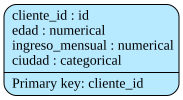

In [54]:
metadata.visualize()

In [55]:
### Entrenar el modedelo de datos sintéticos
# Un sinthetsizer es el encargado de generar los datos sintéticos#

In [56]:
# Le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\arian\anaconda3\envs\Ariana\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [57]:
# Entrenamos el sintetizador con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [58]:
#Generamos los datos sintéticos
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [59]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,39,26406,Yanga
1,4918803,19,3899,Tierra Blanca
2,1900081,21,6435,Paraje
3,531516,20,2561,Paraje
4,10211768,37,14802,Tierra Blanca
...,...,...,...,...
195,1577423,18,6122,Córdoba
196,2804584,18,2049,Córdoba
197,10420935,32,9940,Tierra Blanca
198,16659394,20,8773,Tierra Blanca


In [60]:
dfClientes_falsos.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   cliente_id       200 non-null    int64
 1   edad             200 non-null    int64
 2   ingreso_mensual  200 non-null    int64
 3   ciudad           200 non-null    str  
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [61]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.055000,10666.595000
std,4.707538e+06,12.567485,9166.867964
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2729.000000
50%,9.212590e+06,20.000000,7975.000000
75%,1.279456e+07,30.000000,16171.250000
max,1.677377e+07,70.000000,35000.000000


In [62]:
#Evaluamos los datos para validar
#1. parecido entre las columnas (Columns Shapes Score)
#2. Parecido entre las relaciones de las columnas
#3. Evaluación del dataset general

In [64]:
#Evaluamos la calidad de los datos
#Creamos una instancia de QualityReport
reporte = QualityReport()

## Puntos de referencia
|Score | Interpretación |
|------|----------------|
|1 | Identicas |
|2 | Muy similar |
|3 | Similar |
|4 | Diferencias visibles |
|5 | Muy diferentes |

In [68]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 307.91it/s]|
Column Shapes Score: 74.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 111.29it/s]|
Column Pair Trends Score: 16.5%

Overall Score (Average): 45.5%

